# **Checkpoint 4**

## **Import libery**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Load Datasate**

In [ ]:
path ="/content/drive/MyDrive/checkpoint ke 2/[Bersih] C_PrimatechService.csv"
df = pd.read_csv(path)
df

,service_id,tanggal,provinsi,jenis_servis,jumlah_unit_servis,biaya_servis_per_unit,durasi_servis_per_jam,total_pendapatan,status_servis,rating_pelanggan
0,SVC0001,2024-06-12,Jawa Tengah,AC,4,156081.0,5.300000,624324.0,Dibatalkan,4.0
1,SVC0002,2024-01-07,Jawa Barat,Laptop,5,139045.0,5.100000,695225.0,Proses,5.0
2,SVC0003,2024-03-03,Jawa Tengah,HP,3,5009758.0,2.800000,15029274.0,Dibatalkan,2.0
3,SVC0004,2024-02-05,Dki Jakarta,TV,5,160078.0,1.700000,800390.0,Dibatalkan,3.0
4,SVC0005,2024-06-22,Dki Jakarta,TV,5,392767.0,2.700000,1963835.0,Proses,3.0
...,...,...,...,...,...,...,...,...,...,...
195,SVC0196,2024-07-01,Jawa Barat,AC,3,422771.0,0.800000,1268313.0,Selesai,3.0
196,SVC0197,2024-03-26,Dki Jakarta,TV,3,382460.0,1.300000,1147380.0,Dibatalkan,2.0
197,SVC0198,2024-06-20,Jawa Tengah,TV,1,308067.0,1.200000,308067.0,Pending,5.0
198,SVC0199,2024-09-03,Jawa Timur,TV,5,314512.0,3.164865,1572560.0,Dibatalkan,2.0


## **Line Chart**

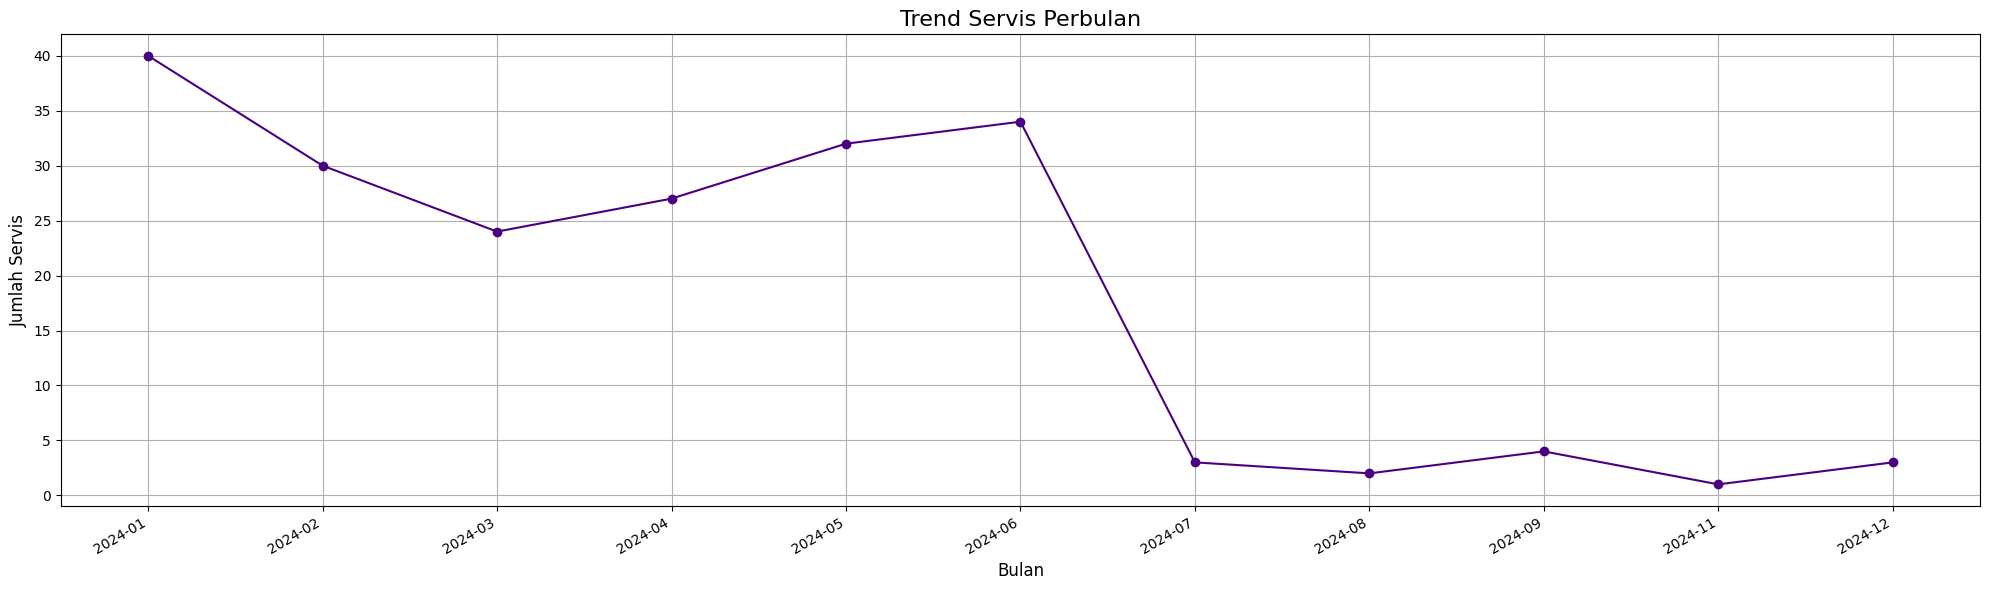

In [ ]:
# Pastikan kolom bertipe datetime
df['tanggal'] = pd.to_datetime(df['tanggal'])
# Group by month
grup_perbulan = df.groupby(df['tanggal'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6)) # Ukuran figure diperbesar untuk kejelasan
plt.plot(grup_perbulan.index.astype(str), grup_perbulan.values, marker='o', color='indigo') # Mengubah warna agar berbeda
plt.title('Trend Servis Per Bulan', fontsize=16) # Judul
plt.xlabel('Bulan', fontsize=12) # X Keterangan
plt.ylabel('Jumlah Servis', fontsize=12) # Y Keterangan
plt.grid(True)
plt.gcf().autofmt_xdate() # Otomatis mengatur format dan rotasi di sumbu X
plt.tight_layout()
plt.show()

**Insight** terjadi penurunan signifikan jumlah servis setelah bulan juni 2024.pada awal tahun jumlah servis relatif tinggi kemudian menurun tajam pada pertengahan tahun dan stabil di angka rendah hingga akhir tahun

**Action** perusahaan perlu mengevaluasi penyebab penurunan setelah juni seperti faktor musiman promosi yang berhenti atau persaingan disarankan melakukan strategi promosi pada bulan dengan jumlah servis rendah

## **Bar Chart**

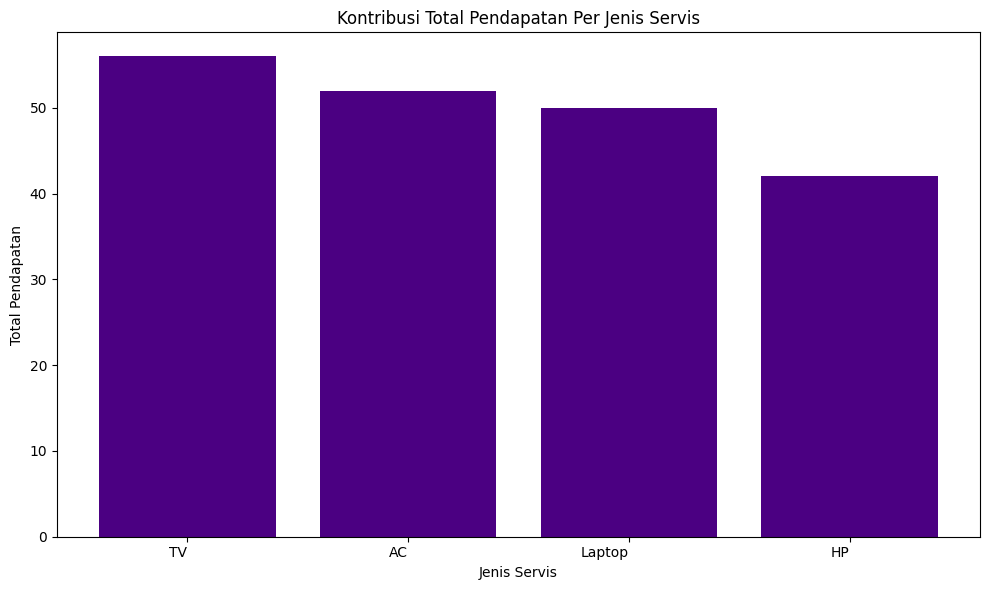

In [14]:
Pendapatan = df['jenis_servis'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(Pendapatan.index, Pendapatan.values, color='indigo') # color warna
plt.xlabel('Jenis Servis') # keterangan X label
plt.ylabel('Total Pendapatan') # keterangan y label
plt.title('Kontribusi Total Pendapatan Per Jenis Servis') # Judul
plt.xticks(rotation=0, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

**Insight** Berdasarkan grafik jenis servis TV memberikan kontribusi pendapatan terbesar dibandingkan jenis servis lainnya Hal ini menunjukkan bahwa layanan perbaikan TV memiliki permintaan atau nilai transaksi yang lebih tinggi sehingga menjadi sumber utama pendapatan perusahaan Sementara itu jenis servis lainnya memberikan kontribusi yang relatif lebih kecil terhadap total pendapatan

**Action** Perusahaan perlu mempertahankan performa servis TV dengan menjaga kualitas layanan dan ketersediaan teknisi yang kompeten Selain itu perusahaan dapat memanfaatkan popularitas servis TV sebagai strategi pemasaran utama Untuk jenis servis dengan kontribusi lebih rendah perlu dilakukan evaluasi strategi harga, promosi, atau peningkatan kualitas layanan agar kontribusi pendapatannya meningkat.

## **Scatter Plot**

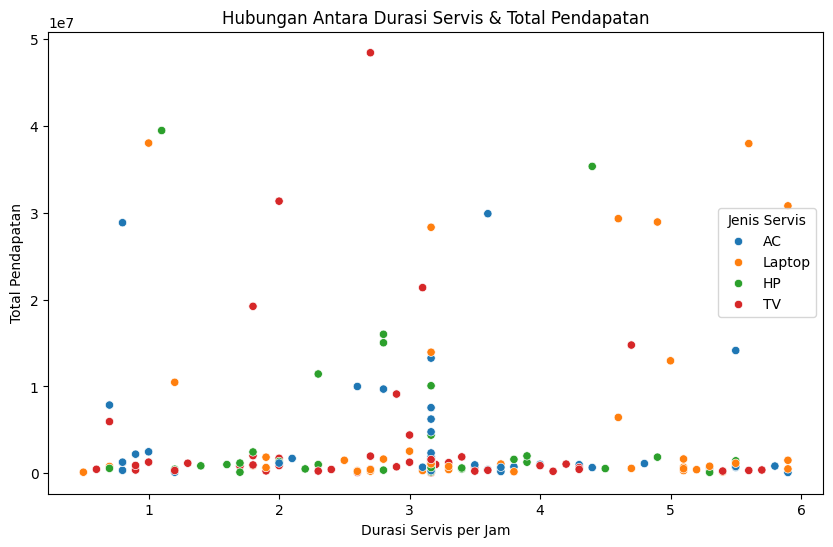

In [16]:
plt.figure(figsize=(10, 6)) # Ukuran
sns.scatterplot(x='durasi_servis_per_jam', y='total_pendapatan', hue='jenis_servis', data=df)
plt.title('Hubungan Antara Durasi Servis & Total Pendapatan') # Judul
plt.xlabel('Durasi Servis per Jam') # X Keterangan
plt.ylabel('Total Pendapatan') # Y Keterangan
plt.legend(title='Jenis Servis') # Keterangan dalam kotak kecil
plt.show()

**Insight** Berdasarkan scatter plot tidak terlihat pola hubungan linear yang kuat antara durasi servis per jam dan total pendapatan Titik-titik data cenderung menyebar secara acak meskipun terdapat beberapa nilai pendapatan tinggi pada durasi tertentu Hal ini menunjukkan bahwa lamanya durasi servis tidak secara langsung menentukan besarnya pendapatan yang diperoleh

**Action** Perusahaan sebaiknya tidak hanya berfokus pada durasi servis sebagai faktor peningkat pendapatan Sebaliknya perlu mempertimbangkan faktor lain seperti jenis servis, kompleksitas kerusakan, dan strategi harga. Selain itu optimalisasi efisiensi waktu servis dapat dilakukan agar perusahaan tetap produktif tanpa harus memperpanjang durasi pengerjaan

## **Heatmap**

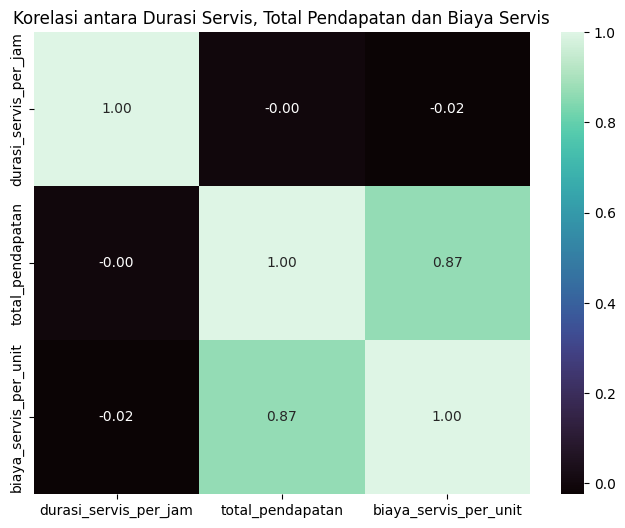

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['durasi_servis_per_jam', 'total_pendapatan', 'biaya_servis_per_unit']].corr(),
            annot=True,
            cmap='mako',
            fmt='.2f')
plt.title('Korelasi antara Durasi Servis, Total Pendapatan dan Biaya Servis')
plt.show()

**Insight** Berdasarkan heatmap korelasi hubungan antara durasi_servis_per_jam dan total_pendapatan sebesar -0.00 menunjukkan tidak adanya hubungan linear antara lamanya pengerjaan servis dengan total pendapatan Korelasi antara durasi_servis_per_jam dan biaya_servis_per_unit sebesar -0.02 juga sangat lemah sehingga durasi servis tidak berkaitan dengan biaya per unit Sebaliknya korelasi antara total_pendapatan dan biaya_servis_per_unit sebesar 0.87 menunjukkan hubungan positif yang sangat kuat yang berarti peningkatan biaya servis per unit berbanding lurus dengan peningkatan total pendapatan

**Action** Berdasarkan hasil tersebut perusahaan sebaiknya tidak berfokus pada penambahan durasi servis untuk meningkatkan pendapatan karena tidak terbukti berpengaruh signifikan Strategi yang lebih efektif adalah mengoptimalkan penetapan biaya servis per unit dan memastikan struktur harga mampu meningkatkan revenue tanpa mengurangi daya saing Selain itu perusahaan dapat memprioritaskan layanan dengan nilai biaya per unit yang lebih tinggi untuk memaksimalkan total pendapatan secara keseluruhan